# Response Surface Reconstruction

This notebook demonstrates local response surface methodology (RSM) reconstruction for hydrothermal treatment predictions. It fits quadratic surfaces around experimental blocks defined by (DOI, Feedstock) to visualize model behavior and identify optimal operating conditions.

**Key Features:**
- 3D surface visualization of target predictions vs. temperature (T) and time (t)
- Local quadratic response surface fitting to RF predictions
- Optimal condition identification within experimental blocks
- Comparison across different feedstocks and studies

**Workflow:**
1. Load trained RF models and test data
2. Select experimental blocks (DOI + Feedstock combinations)
3. Generate prediction surfaces over T-t grid
4. Fit local RSM and identify optima
5. Visualize 3D surfaces with data points

In [88]:
import os
import sys
import json
import numpy as np
import pandas as pd
import joblib
from pathlib import Path

notebook_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
project_root = notebook_dir.parent
src_dir = project_root / 'src'
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from data_preparation import build_training_features

DATA_DIR = project_root / 'data'
MODELS_DIR = project_root / 'models' / 'saved_models_global_with_tier_subprocess_catalyst_lri'
OUTPUTS_DIR = project_root / 'outputs'
TABLES_DIR = OUTPUTS_DIR / 'tables'
FIGURES_DIR = OUTPUTS_DIR / 'figures'

print(f"Project root: {project_root}")
print(f"Models directory: {MODELS_DIR}")
print(f"Data directory: {DATA_DIR}")

feature_json = notebook_dir / 'Testing' / 'feature_lists.json'
if feature_json.exists():
    with open(feature_json, 'r') as f:
        feat_data = json.load(f)
    X_cols = feat_data.get('X_cols', [])
    Y_cols = feat_data.get('Y_cols', [])
    print(f"Loaded {len(X_cols)} X features, {len(Y_cols)} Y targets from: {feature_json.name}")
else:
    print(f"Feature list not found at {feature_json}, will use default target list")

Project root: /home/Elfetni/ML_UQ_LCA_pipeline/ml_uq_hydrothermal_pipeline
Models directory: /home/Elfetni/ML_UQ_LCA_pipeline/ml_uq_hydrothermal_pipeline/models/saved_models_global_with_tier_subprocess_catalyst_lri
Data directory: /home/Elfetni/ML_UQ_LCA_pipeline/ml_uq_hydrothermal_pipeline/data
Loaded 136 X features, 28 Y targets from: feature_lists.json


In [89]:
COLS_Y = [
    "B_Y", "C_Y", "A_Y", "G_Y",
    "E_B", "E_H", "C_B", "C_H",
    "HHV_biooil", "C_biooil", "O_biooil", "H_biooil", "N_biooil", "S_biooil",
    "HHV_biochar", "C_biochar", "O_biochar", "H_biochar", "N_biochar", "S_biochar",
    "O/C_biooil", "H/C_biooil", "O/C_biochar", "H/C_biochar",
]
print(f"Target list contains {len(COLS_Y)} targets")

Target list contains 24 targets


In [90]:
rf_models = {}
for target in COLS_Y:
    safe_target = target.replace("/", "_").replace("\\", "_").replace(":", "_")
    model_path = MODELS_DIR / f"rf_{safe_target}.joblib"
    
    if model_path.exists():
        rf_models[target] = joblib.load(model_path)
    else:
        print(f"Model not found for {target}: {model_path}")

print(f"Loaded {len(rf_models)} RF models from {MODELS_DIR.name}")
print(f"Available targets: {list(rf_models.keys())[:5]}...")

Loaded 24 RF models from saved_models_global_with_tier_subprocess_catalyst_lri
Available targets: ['B_Y', 'C_Y', 'A_Y', 'G_Y', 'E_B']...


## Load X_test and Y_test from Training Data

Load the train/test split from the training notebook to ensure consistency.

In [91]:
X_test_path = notebook_dir / 'X_test.csv'
Y_test_path = notebook_dir / 'Y_test.csv'
X_train_path = notebook_dir / 'X_train.csv'
Y_train_path = notebook_dir / 'Y_train.csv'

if X_test_path.exists() and Y_test_path.exists():
    X_test = pd.read_csv(X_test_path)
    Y_test = pd.read_csv(Y_test_path)
    X_test.index = range(len(X_test))
    Y_test.index = range(len(Y_test))
    print(f"Loaded test set: X_test {X_test.shape}, Y_test {Y_test.shape}")
else:
    raise FileNotFoundError(f"Test set not found at {X_test_path.parent}")

if X_train_path.exists() and Y_train_path.exists():
    X_train = pd.read_csv(X_train_path)
    Y_train = pd.read_csv(Y_train_path)
    X_train.index = range(len(X_train))
    Y_train.index = range(len(Y_train))
    print(f"Loaded train set: X_train {X_train.shape}, Y_train {Y_train.shape}")
else:
    print("Training set not found (only test set loaded)")
    X_train, Y_train = None, None

metadata_cols = ['DOI', 'Feedstock', 'Ref']
if any(c in X_test.columns for c in metadata_cols):
    print(f"Metadata columns available: {[c for c in metadata_cols if c in X_test.columns]}")
else:
    print("No metadata columns found in X_test")

Loaded test set: X_test (697, 136), Y_test (697, 28)
Loaded train set: X_train (2688, 136), Y_train (2688, 28)
No metadata columns found in X_test


In [92]:
X_test.columns

Index(['O/C', 'H/C', 'Ash', 'HHV_feedstock', 'O', 'C', 'H', 'T', 't', 'IC',
       ...
       'frac_glycerol_missing', 'acid_M', 'acid_M_missing', 'base_M',
       'base_M_missing', 'phenol_additive_wt_pct',
       'phenol_additive_wt_pct_missing', 'acid_flag', 'base_flag',
       'H_donor_flag'],
      dtype='object', length=136)

In [93]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from rsm_analysis import (
    run_rsm_block,
    find_rsm_candidates,
    auto_rsm_dashboard,
    get_rsm_meta,
    RSM_TARGET_META
)
from ratio_functions import compute_atomic_ratio, run_rsm_block_with_ratios

plt.style.use('default')
%matplotlib inline

## Response Surface Analysis

The RSM functions are now imported from `src/rsm_analysis.py`:
- `run_rsm_block()` - Main workflow function
- `find_rsm_candidates()` - Identify suitable experimental blocks
- `auto_rsm_dashboard()` - Generate multiple plots
- `get_rsm_meta()` - Target metadata (units, names)

In [94]:
Y_test.columns

Index(['B_Y', 'C_Y', 'A_Y', 'G_Y', 'E_B', 'E_H', 'C_B', 'C_H', 'HHV_biooil',
       'C_biooil', 'O_biooil', 'H_biooil', 'N_biooil', 'S_biooil',
       'HHV_biochar', 'C_biochar', 'O_biochar', 'H_biochar', 'N_biochar',
       'S_biochar', 'O/C_biooil', 'H/C_biooil', 'O/C_biochar', 'H/C_biochar',
       'DOI', 'Ref', 'Feedstock', 'T'],
      dtype='object')


>>> RSM dashboard for Char yield (C_Y)

=== Auto 3D RSM plots for Char yield (C_Y) ===
Will try up to 20 blocks

Feedstocks to plot (2 blocks):
   1. Hazelnut shell (n=15.0, DOI=https://doi.org/10.1016/j.supflu.2019.03.019)
   2. Cunninghamia lanceolata (Chinese fir) (n=10.0, DOI=10.1016/S0360-5442(02)00178-0)

[1] DOI=https://doi.org/10.1016/j.supflu.2019.03.019, Feedstock=Hazelnut shell, n=15, T=220.0-300.0, t=30.0-90.0, catalyst=none, solvent=alcohol_ketone_mix, HTL_solvothermal, opt-> T=219.0, t=29.0, z=74.44 (edge)


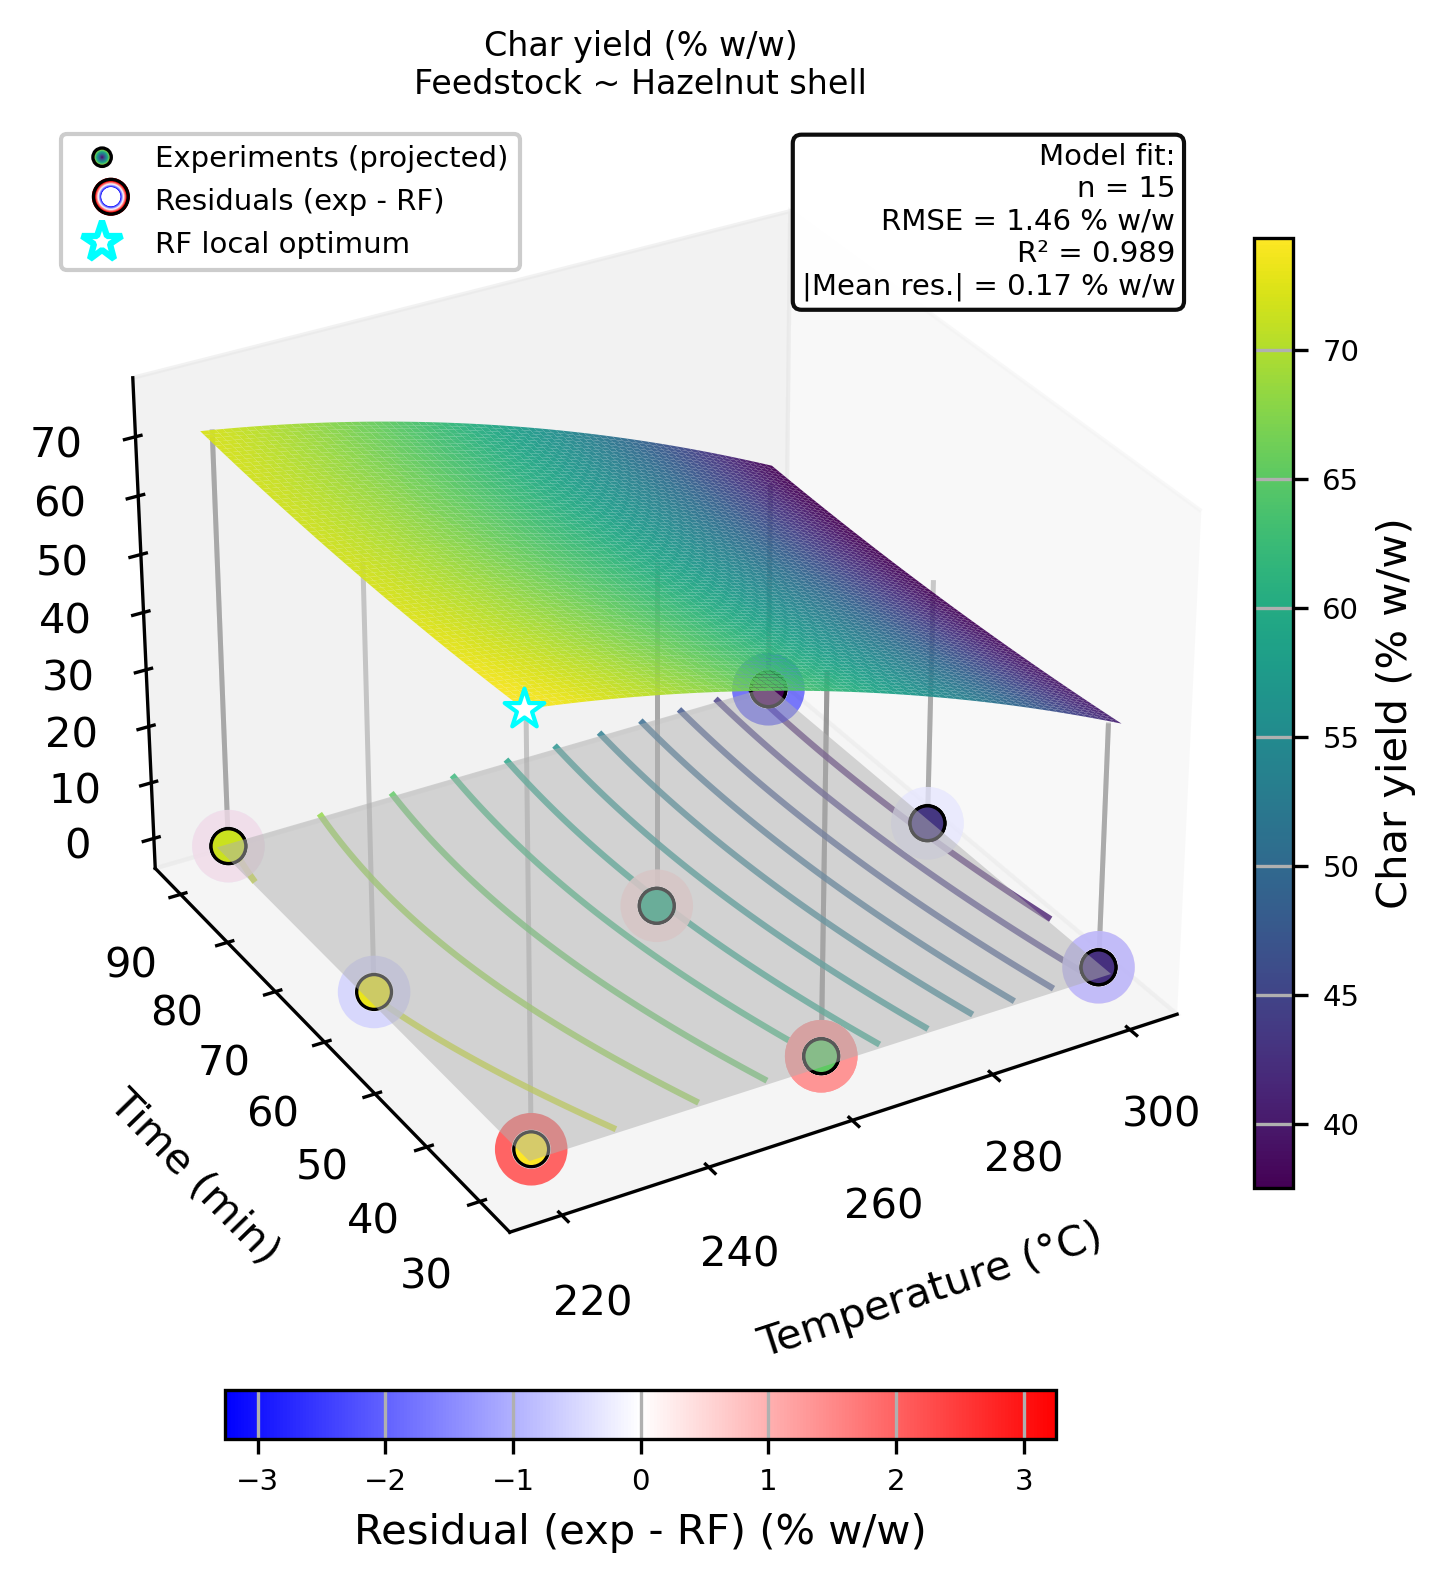

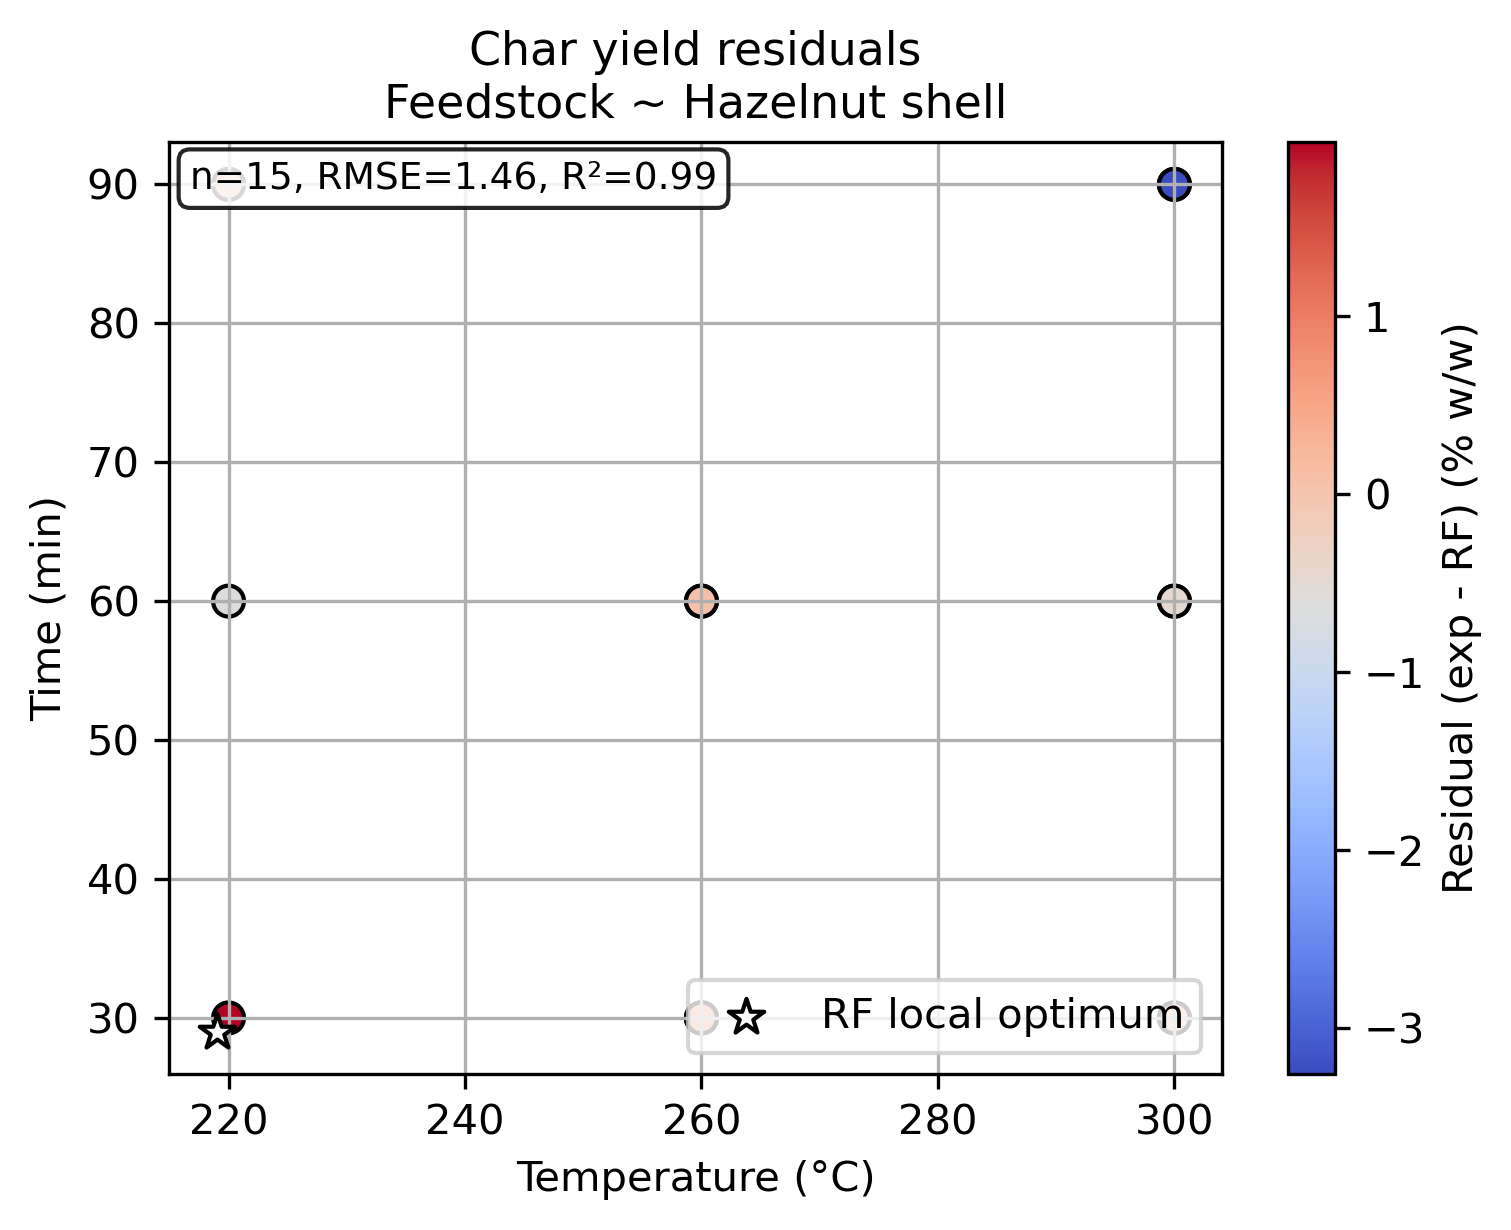

[2] DOI=10.1016/S0360-5442(02)00178-0, Feedstock=Cunninghamia lanceolata (Chinese fir), n=10, T=280.0-360.0, t=10.0-30.0, catalyst=none, solvent=water, HTL, opt-> T=279.0, t=12.3, z=40.32 (edge)


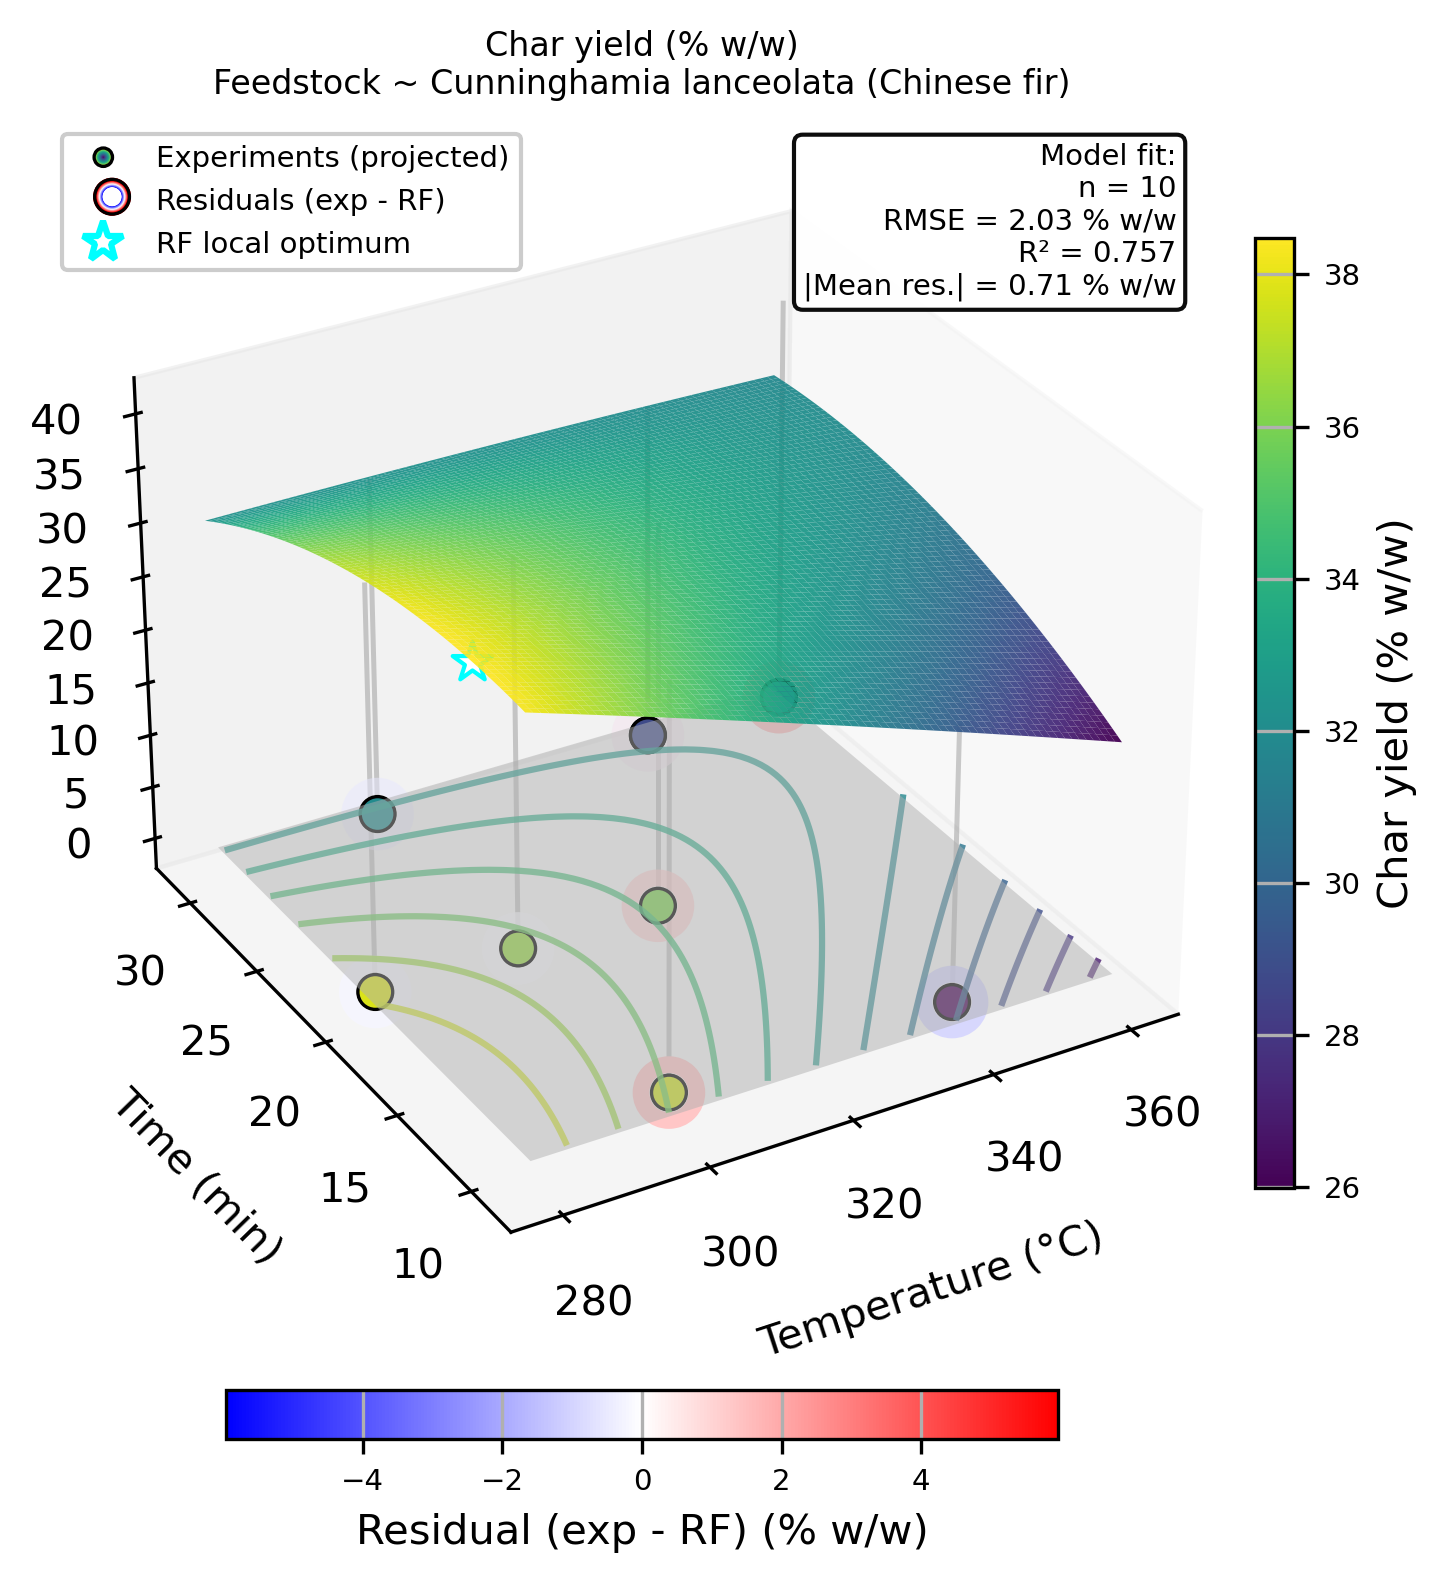

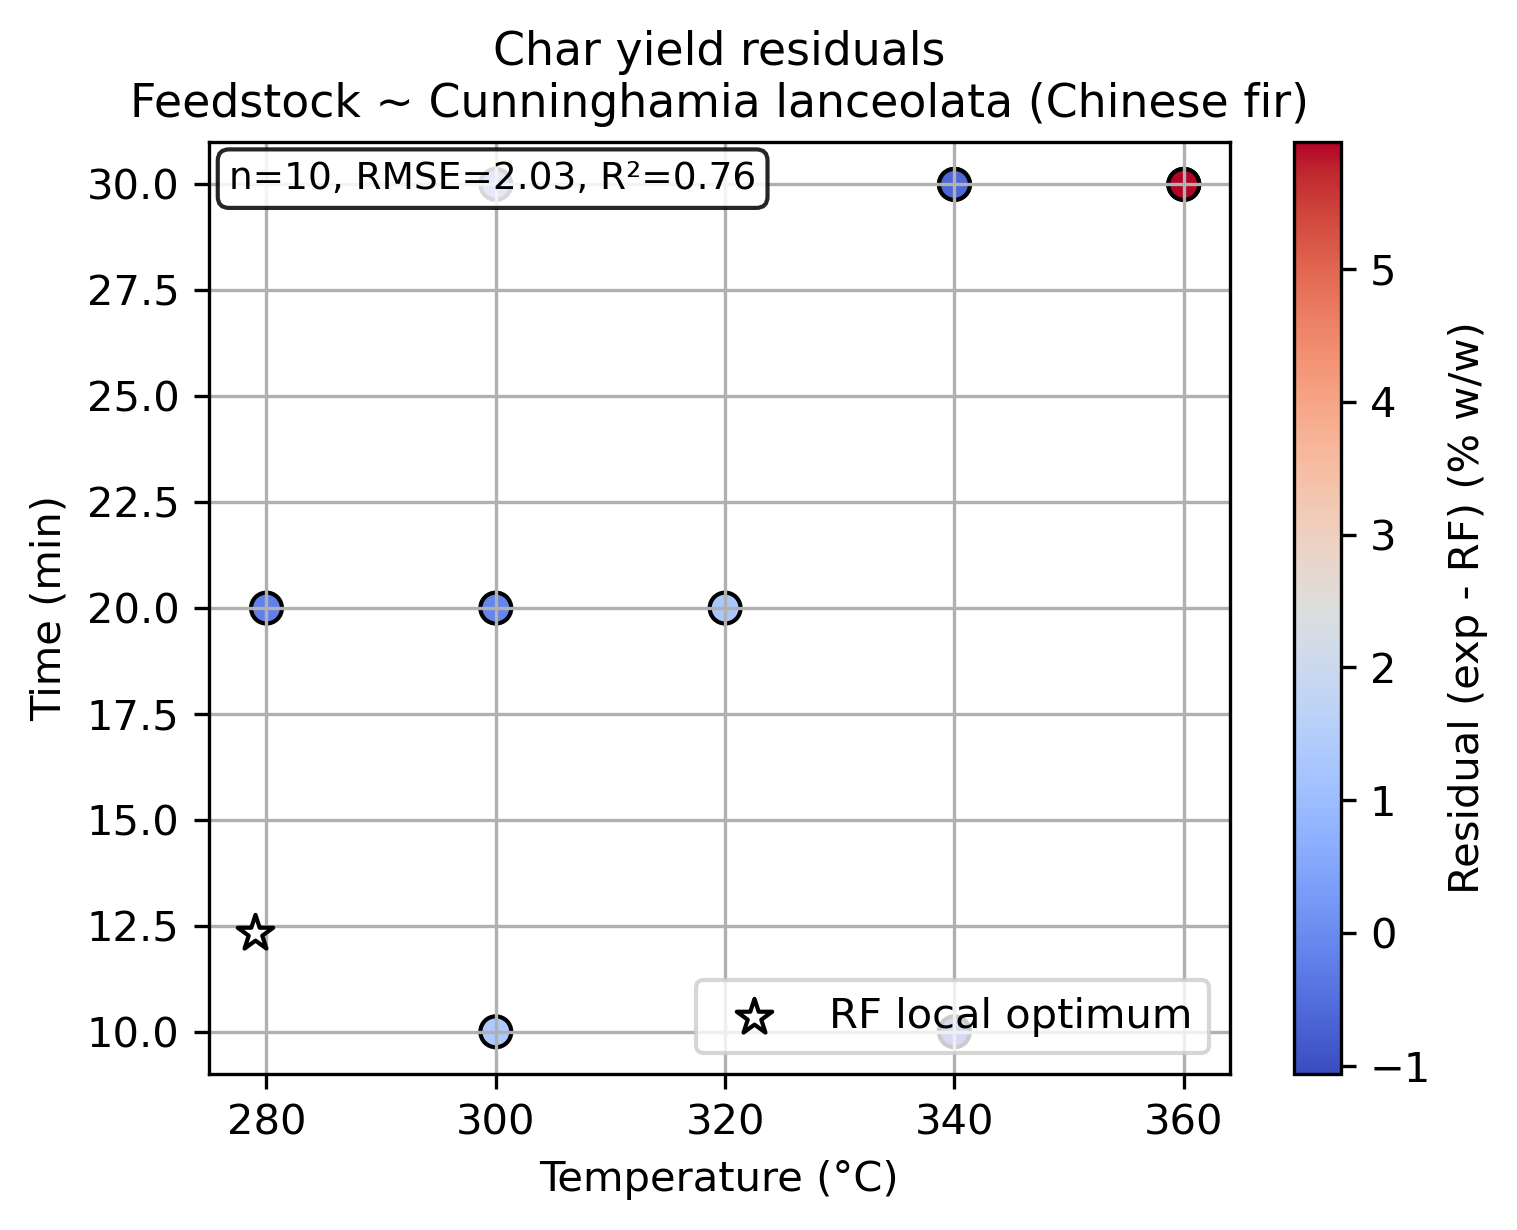


Produced 2 RSM blocks for Char yield


In [96]:
summary = run_rsm_block(
    target="C_Y",
    X=X_test,
    Y=Y_test,
    models=rf_models,
    x_col="T",
    y_col="t",
    extrapolation_absolute={"T": 1, "t": 1},
)